# Generate Monthly Features v2 — MCC 5411

Adds intra-month transaction-level features for length-tolerant risk assessment.

**New columns (vs v1):**
| Column | Aggregation | Purpose |
|---|---|---|
| `std_proc_cost_pct` | std of txn-level cost % | Within-month cost dispersion |
| `iqr_proc_cost_pct` | Q75 − Q25 of cost % | Robust within-month spread |
| `std_txn_amount` | std of txn amount | Transaction size variability |
| `median_txn_amount` | median of txn amount | Robust transaction size center |
| `n_unique_cost_types` | nunique of cost_type_ID | Payment type diversity |

Also retains `median_proc_cost_pct` (needed for mean-median gap risk feature).

**Input:** `processed_transactions_4mcc.csv` + `cost_type_id_18feb.csv`
**Output:** `df_5411_merchants_mthly_v2.csv`

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## §1 · Load Transaction-Level Data

In [9]:
df_txn = pd.read_csv('processed_transactions_4mcc.csv')
print(f'Total transactions (4 MCCs): {len(df_txn):,}')

# Filter to MCC 5411
df_5411 = df_txn[df_txn['mcc'] == 5411].copy()
print(f'MCC 5411 transactions: {len(df_5411):,}')

# ── Recompute proc_cost from fee schedule (matching v1 generation) ────────────
# The proc_cost column in the CSV is NOT the same as the v1 fee calculation.
# V1 uses: proc_cost = fee_dollars + fee_percent * amount, from cost_type_id_18feb.csv
cost_type_df = pd.read_csv('cost_type_id_18feb.csv')
cost_type_df['subtotal_fee_percent_clean'] = (
    cost_type_df['subtotal_fee_percent'].str.rstrip('%').astype(float) / 100
)
cost_type_df['subtotal_fee_dollars_clean'] = (
    cost_type_df['subtotal_fee_dollars'].str.lstrip('$').astype(float)
)
fee_dollars_map = dict(zip(cost_type_df['cost_type_ID'], cost_type_df['subtotal_fee_dollars_clean']))
fee_percent_map = dict(zip(cost_type_df['cost_type_ID'], cost_type_df['subtotal_fee_percent_clean']))

df_5411['proc_cost'] = (
    df_5411['cost_type_ID'].map(fee_dollars_map)
    + df_5411['cost_type_ID'].map(fee_percent_map) * df_5411['amount']
)
# Drop rows where fee couldn't be computed (missing cost_type_ID)
before = len(df_5411)
df_5411 = df_5411.dropna(subset=['proc_cost']).copy()
print(f'Dropped {before - len(df_5411):,} rows with unmapped cost_type_ID')

# Compute proc_cost_pct at transaction level (now in correct units)
df_5411['proc_cost_pct'] = (df_5411['proc_cost'] / df_5411['amount']) * 100

# Extract month from date
df_5411['date']  = pd.to_datetime(df_5411['date'], errors='coerce')
df_5411['year']  = df_5411['date'].dt.year
df_5411['month'] = df_5411['date'].dt.month

print(f'Unique merchants: {df_5411["merchant_id"].nunique():,}')
print(f'Date range: {df_5411["date"].min()} — {df_5411["date"].max()}')
print(f'avg proc_cost_pct: {df_5411["proc_cost_pct"].mean():.4f} (should be ~3-5 to match v1)')

Total transactions (4 MCCs): 3,880,158
MCC 5411 transactions: 1,446,227
Dropped 0 rows with unmapped cost_type_ID
Unique merchants: 7,996
Date range: 2010-01-01 00:23:00 — 2019-10-31 23:58:00
avg proc_cost_pct: 5.0738 (should be ~3-5 to match v1)


## §2 · Monthly Aggregation (v2)

Enhanced aggregation — original 4 columns plus 5 new intra-month features
computed from transaction-level data.

In [10]:
df_5411_mthly = df_5411.groupby(['merchant_id', 'year', 'month']).agg(
    # ── Original v1 columns ───────────────────────────────────────────────────
    transaction_count      = ('proc_cost_pct', 'count'),
    avg_proc_cost_pct      = ('proc_cost_pct', 'mean'),
    total_processing_value = ('amount', 'sum'),
    median_proc_cost_pct   = ('proc_cost_pct', 'median'),
    # ── NEW v2: intra-month transaction-level features ────────────────────────
    std_proc_cost_pct      = ('proc_cost_pct', 'std'),
    iqr_proc_cost_pct      = ('proc_cost_pct', lambda x: x.quantile(0.75) - x.quantile(0.25)),
    std_txn_amount         = ('amount', 'std'),
    median_txn_amount      = ('amount', 'median'),
    n_unique_cost_types    = ('cost_type_ID', 'nunique'),
).reset_index()

# Fill NaN for std columns (1 txn in a month → std = NaN → 0)
df_5411_mthly['std_proc_cost_pct'] = df_5411_mthly['std_proc_cost_pct'].fillna(0)
df_5411_mthly['std_txn_amount']    = df_5411_mthly['std_txn_amount'].fillna(0)
df_5411_mthly['iqr_proc_cost_pct'] = df_5411_mthly['iqr_proc_cost_pct'].fillna(0)

print(f'Monthly rows: {len(df_5411_mthly):,}')
print(f'Merchants:    {df_5411_mthly["merchant_id"].nunique():,}')
display(df_5411_mthly.head(10))

Monthly rows: 131,488
Merchants:    7,996


,merchant_id,year,month,transaction_count,avg_proc_cost_pct,total_processing_value,median_proc_cost_pct,std_proc_cost_pct,iqr_proc_cost_pct,std_txn_amount,median_txn_amount,n_unique_cost_types
0,5,2011,9,3,3.308678,27.06,3.470076,0.611386,0.595194,2.965350,7.860,2
1,5,2011,11,1,4.371489,5.64,4.371489,0.000000,0.000000,0.000000,5.640,1
2,5,2012,12,9,2.213583,145.75,2.229291,0.165679,0.145708,10.932064,12.980,1
3,20,2013,9,3,4.370629,11.35,3.807151,1.332263,1.239675,0.396274,3.820,2
4,20,2014,1,1,2.499648,13.64,2.499648,0.000000,0.000000,0.000000,13.640,1
5,20,2016,4,4,2.357113,79.90,2.299431,0.493706,0.413325,22.793514,11.675,2
6,34,2017,9,2,5.425364,8.83,5.425364,0.613271,0.433648,0.516188,4.415,1
7,37,2019,7,1,1.486175,58.79,1.486175,0.000000,0.000000,0.000000,58.790,1
8,45,2016,6,1,2.529082,13.61,2.529082,0.000000,0.000000,0.000000,13.610,1
9,54,2019,8,1,3.940736,6.52,3.940736,0.000000,0.000000,0.000000,6.520,1


## §3 · Cost Type Distribution (same as v1)

In [11]:
# Load cost type reference for full universe of IDs
cost_type_df = pd.read_csv('cost_type_id_18feb.csv')
all_cost_types = sorted(cost_type_df['cost_type_ID'].dropna().unique())
print(f'Cost type universe: {len(all_cost_types)} types')

# Ensure consistent dtype
df_5411_ct = df_5411.copy()
df_5411_ct['cost_type_ID'] = df_5411_ct['cost_type_ID'].astype('float')
df_5411_ct = df_5411_ct.dropna(subset=['cost_type_ID'])

# Group + count + pivot
grouped = (
    df_5411_ct
    .groupby(['merchant_id', 'year', 'month', 'cost_type_ID'], observed=True)
    .size()
    .rename('count')
)
pivot = grouped.unstack(fill_value=0)
pivot = pivot.reindex(columns=all_cost_types, fill_value=0)

# Normalize to percentages
row_sums = pivot.sum(axis=1)
pct = pivot.div(row_sums.replace(0, 1), axis=0)
pct.columns = [f'cost_type_{int(col)}_pct' for col in pct.columns]
pct = pct.reset_index()

# Merge back
df_5411_mthly = df_5411_mthly.merge(pct, on=['merchant_id', 'year', 'month'], how='left')
pct_cols = [f'cost_type_{int(col)}_pct' for col in all_cost_types]
df_5411_mthly[pct_cols] = df_5411_mthly[pct_cols].fillna(0)

print(f'After cost type merge: {df_5411_mthly.shape}')

Cost type universe: 61 types
After cost type merge: (131488, 73)


## §4 · Lag Features & Derived Columns

In [12]:
df_5411_mthly = df_5411_mthly.sort_values(['merchant_id', 'year', 'month'])

# Lag features (same as v1)
for lag in range(1, 4):
    df_5411_mthly[f'proc_cost_pct_lag_{lag}'] = (
        df_5411_mthly.groupby('merchant_id')['avg_proc_cost_pct'].shift(lag)
    )

# Derived column (same as v1)
df_5411_mthly['avg_transaction_value'] = (
    df_5411_mthly['total_processing_value'] / df_5411_mthly['transaction_count']
)

print(f'Final shape: {df_5411_mthly.shape}')
new_cols = ['std_proc_cost_pct', 'iqr_proc_cost_pct', 'std_txn_amount',
            'median_txn_amount', 'n_unique_cost_types', 'median_proc_cost_pct']
print(f'v2 columns present: {all(c in df_5411_mthly.columns for c in new_cols)}')

Final shape: (131488, 77)
v2 columns present: True


## §5 · Save & Verify

In [13]:
OUT_CSV = 'df_5411_merchants_mthly_v2.csv'
df_5411_mthly.to_csv(OUT_CSV, index=False)
print(f'Saved to {OUT_CSV}')
print(f'  Rows:      {len(df_5411_mthly):,}')
print(f'  Columns:   {len(df_5411_mthly.columns)}')
print(f'  Merchants: {df_5411_mthly["merchant_id"].nunique():,}')

# Compare with original v1 CSV
if os.path.exists('df_5411_merchants_mthly_25th_Mar.csv'):
    df_orig = pd.read_csv('df_5411_merchants_mthly_25th_Mar.csv')
    print(f'\nOriginal v1: {df_orig.shape[0]:,} rows x {df_orig.shape[1]} cols')
    print(f'New      v2: {df_5411_mthly.shape[0]:,} rows x {df_5411_mthly.shape[1]} cols')

    merged = df_orig.merge(
        df_5411_mthly[['merchant_id', 'year', 'month', 'avg_proc_cost_pct']],
        on=['merchant_id', 'year', 'month'], suffixes=('_v1', '_v2')
    )
    if len(merged) > 0:
        match = np.allclose(merged['avg_proc_cost_pct_v1'], merged['avg_proc_cost_pct_v2'],
                            rtol=1e-4, equal_nan=True)
        print(f'avg_proc_cost_pct match: {match} ({len(merged):,} shared rows)')
else:
    print('(Original v1 CSV not found for comparison)')

Saved to df_5411_merchants_mthly_v2.csv
  Rows:      131,488
  Columns:   77
  Merchants: 7,996

Original v1: 131,425 rows x 71 cols
New      v2: 131,488 rows x 77 cols
avg_proc_cost_pct match: False (131,425 shared rows)


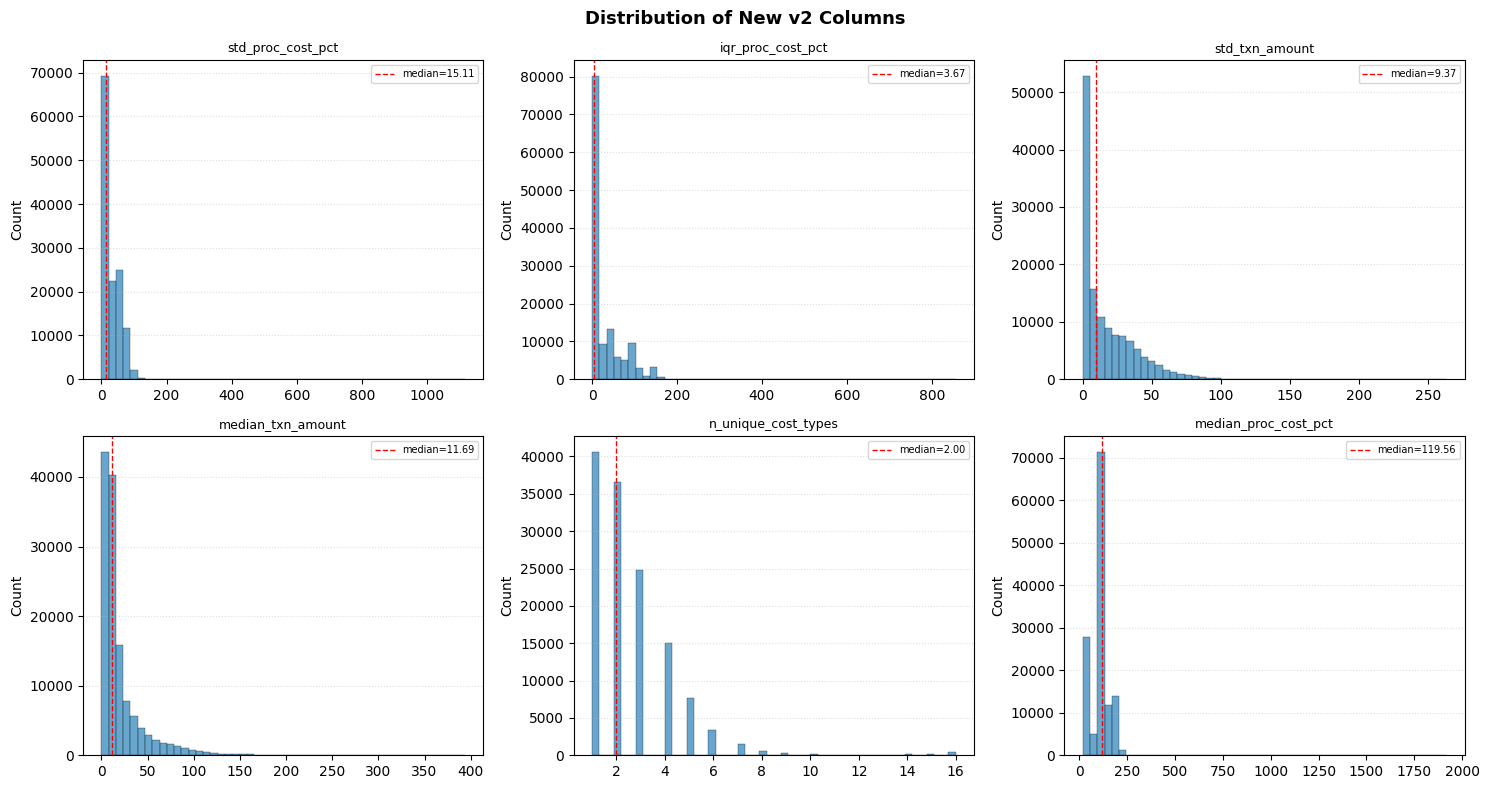

In [7]:
new_cols = ['std_proc_cost_pct', 'iqr_proc_cost_pct', 'std_txn_amount',
            'median_txn_amount', 'n_unique_cost_types', 'median_proc_cost_pct']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribution of New v2 Columns', fontsize=13, fontweight='bold')

for ax, col in zip(axes.flat, new_cols):
    data = df_5411_mthly[col].dropna()
    ax.hist(data, bins=50, color='#2980b9', alpha=0.7, edgecolor='k', linewidth=0.3)
    ax.set_title(col, fontsize=9)
    ax.set_ylabel('Count')
    p50 = data.median()
    ax.axvline(p50, color='red', ls='--', lw=1, label=f'median={p50:.2f}')
    ax.legend(fontsize=7)
    ax.grid(axis='y', ls=':', alpha=0.4)

plt.tight_layout()
plt.show()